In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

%matplotlib inline

In [2]:
DATA_PATH = (
    "../data/features/"
    "nifty50_features.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Date"],
)

df.head()

,Date,Open,High,Low,Close,Volume,return,log_return,volatility_20d,rsi_14,macd,macd_signal,macd_histogram,atr_14,volume_change,volume_ma_20
0,2022-02-01,17529.449219,17622.400391,17244.550781,17576.849609,386400,0.013668,0.013575,0.010512,60.680331,-117.236885,-45.520134,-71.716751,290.674486,0.201119,281070.0
1,2022-02-02,17706.199219,17794.599609,17674.800781,17780.000000,271200,0.011558,0.011492,0.010586,64.074128,-88.394175,-54.094942,-34.299233,285.465594,-0.298137,282260.0
2,2022-02-03,17767.750000,17781.150391,17511.150391,17560.199219,226600,-0.012362,-0.012439,0.010804,58.218993,-82.323235,-59.740601,-22.582634,284.360909,-0.164454,281015.0
3,2022-02-04,17590.199219,17617.800781,17462.550781,17516.300781,261400,-0.002500,-0.002503,0.010602,57.096792,-80.130513,-63.818583,-16.311930,275.138701,0.153575,282260.0
4,2022-02-07,17456.300781,17536.750000,17119.400391,17213.599609,265000,-0.017281,-0.017432,0.011181,49.947410,-101.646503,-71.384167,-30.262336,285.296623,0.013772,283545.0


In [3]:
print("Shape:", df.shape)

print("\nDate range:")
print(df["Date"].min())
print(df["Date"].max())

print("\nColumns:")
print(df.columns.tolist())

Shape: (1110, 16)

Date range:
2022-02-01 00:00:00
2026-07-31 00:00:00

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'return', 'log_return', 'volatility_20d', 'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'atr_14', 'volume_change', 'volume_ma_20']


In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1110,2024-04-30 16:27:14.594594816,2022-02-01 00:00:00,2023-03-14 06:00:00,2024-05-04 12:00:00,2025-06-16 18:00:00,2026-07-31 00:00:00,NaN
Open,1110.0,21544.825994,15272.650391,18180.350098,22426.875,24422.537109,26333.699219,3240.619299
High,1110.0,21640.583777,15382.5,18252.836914,22521.599609,24570.312012,26373.199219,3250.051145
Low,1110.0,21431.186531,15183.400391,18079.062988,22304.525391,24326.162598,26210.050781,3234.196734
Close,1110.0,21538.183357,15293.5,18161.299316,22412.774414,24446.711914,26328.550781,3240.080521
Volume,1110.0,308903.693694,0.0,241475.0,284500.0,356975.0,1198000.0,107591.821145
return,1110.0,0.000345,-0.059294,-0.004146,0.000428,0.005304,0.038183,0.008706
log_return,1110.0,0.000307,-0.061124,-0.004155,0.000428,0.00529,0.037472,0.008718
volatility_20d,1110.0,0.008126,0.003161,0.005821,0.007278,0.00937,0.019047,0.003323
rsi_14,1110.0,53.423134,21.788395,44.52775,53.556848,61.820186,85.256264,12.094756


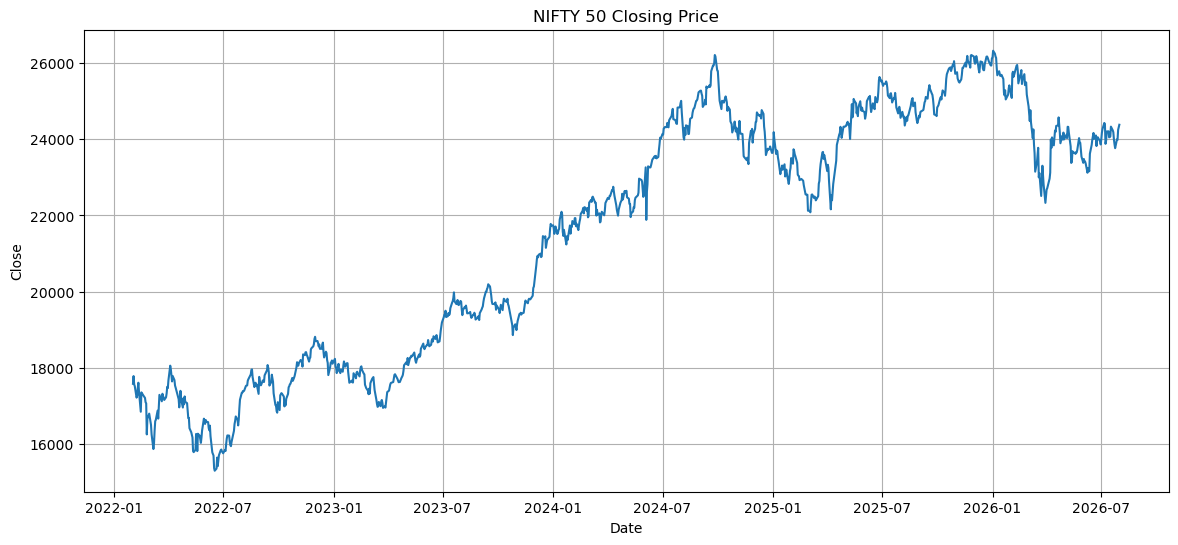

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Close"],
)

plt.title(
    "NIFTY 50 Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Close")

plt.grid(True)
plt.show()

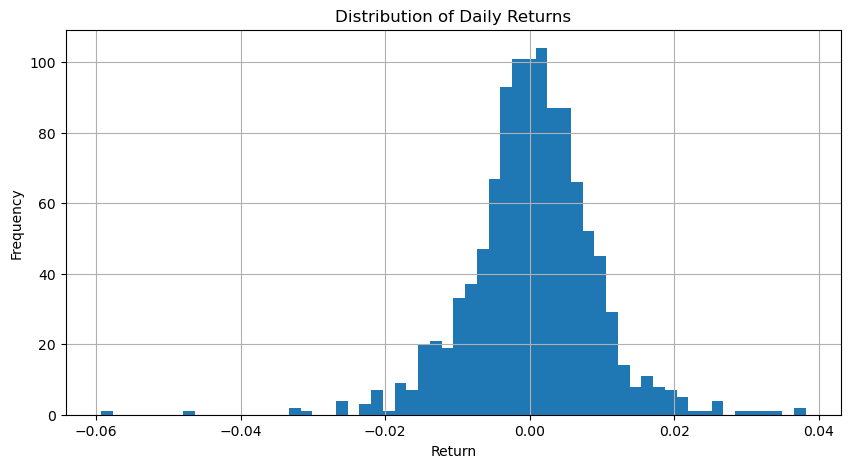

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["return"],
    bins=60,
)

plt.title(
    "Distribution of Daily Returns"
)

plt.xlabel("Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

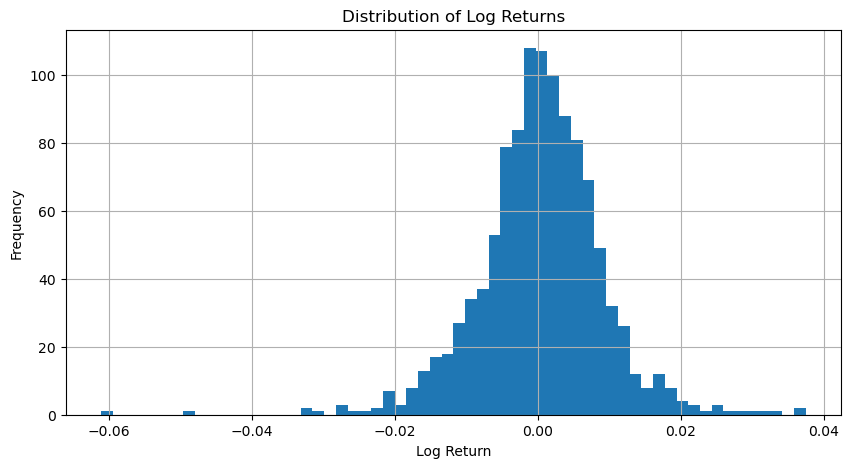

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["log_return"],
    bins=60,
)

plt.title(
    "Distribution of Log Returns"
)

plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

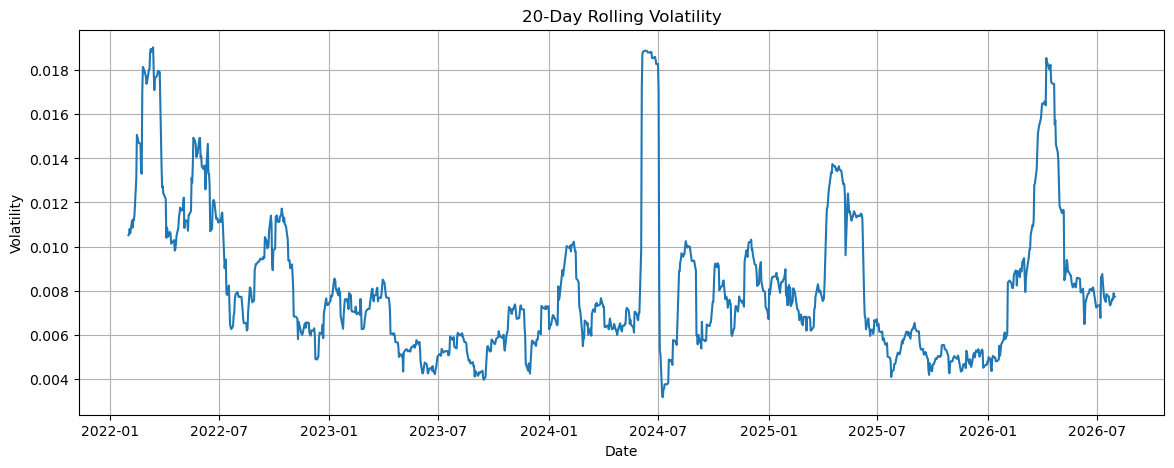

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["volatility_20d"],
)

plt.title(
    "20-Day Rolling Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

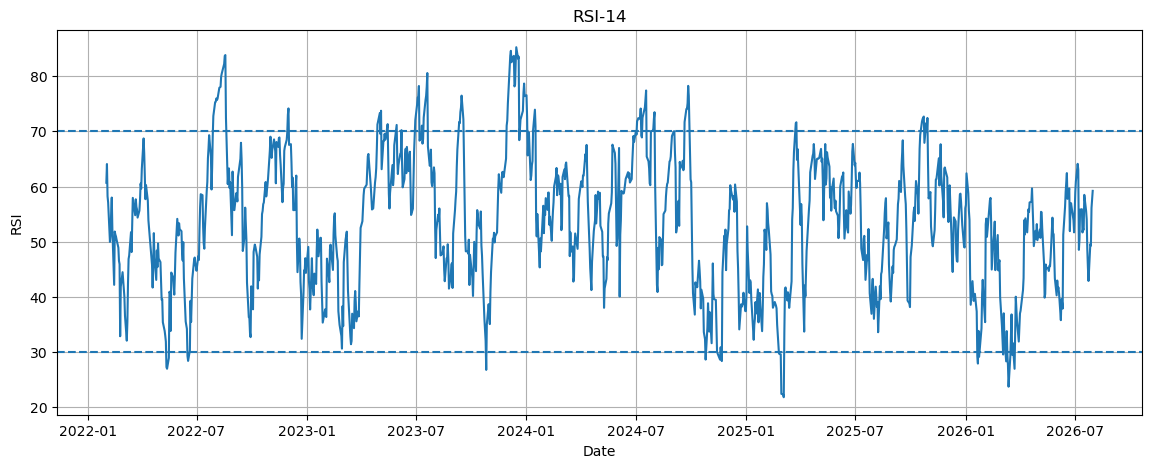

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["rsi_14"],
)

plt.axhline(
    70,
    linestyle="--",
)

plt.axhline(
    30,
    linestyle="--",
)

plt.title(
    "RSI-14"
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.grid(True)
plt.show()

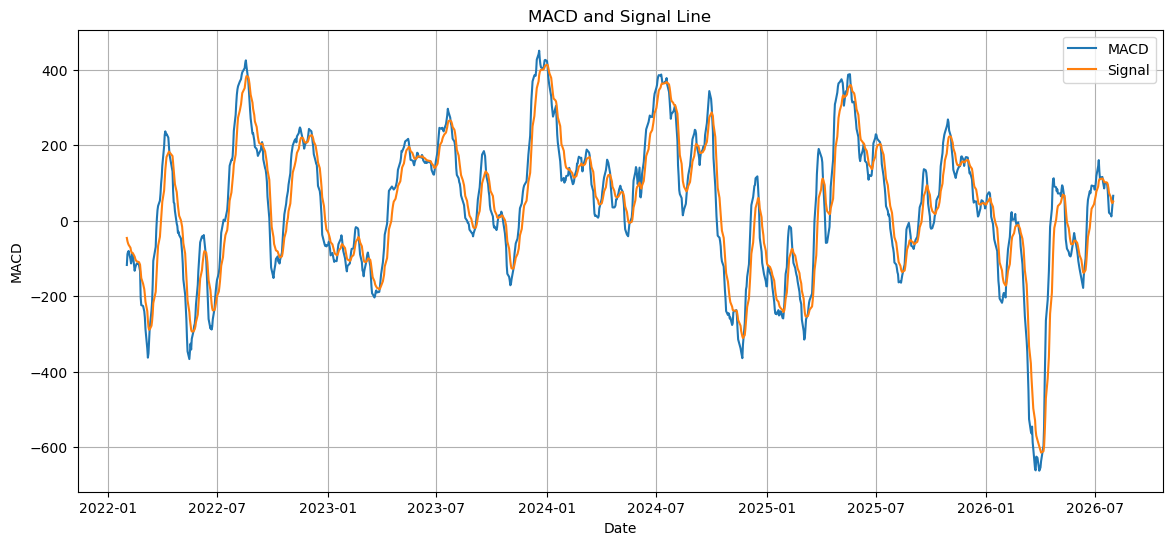

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["macd"],
    label="MACD",
)

plt.plot(
    df["Date"],
    df["macd_signal"],
    label="Signal",
)

plt.title(
    "MACD and Signal Line"
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()
plt.grid(True)
plt.show()

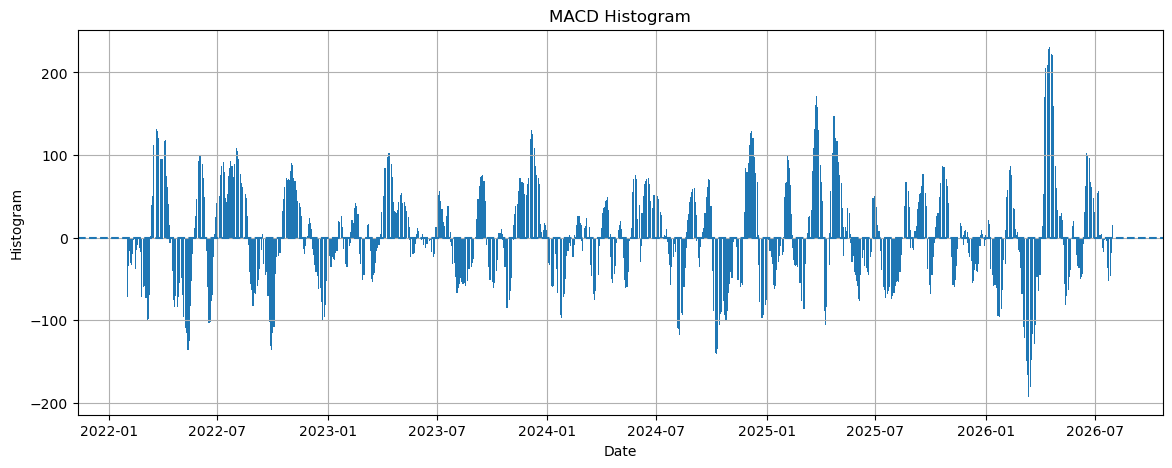

In [11]:
plt.figure(figsize=(14, 5))

plt.bar(
    df["Date"],
    df["macd_histogram"],
    width=2,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    "MACD Histogram"
)

plt.xlabel("Date")
plt.ylabel("Histogram")

plt.grid(True)
plt.show()

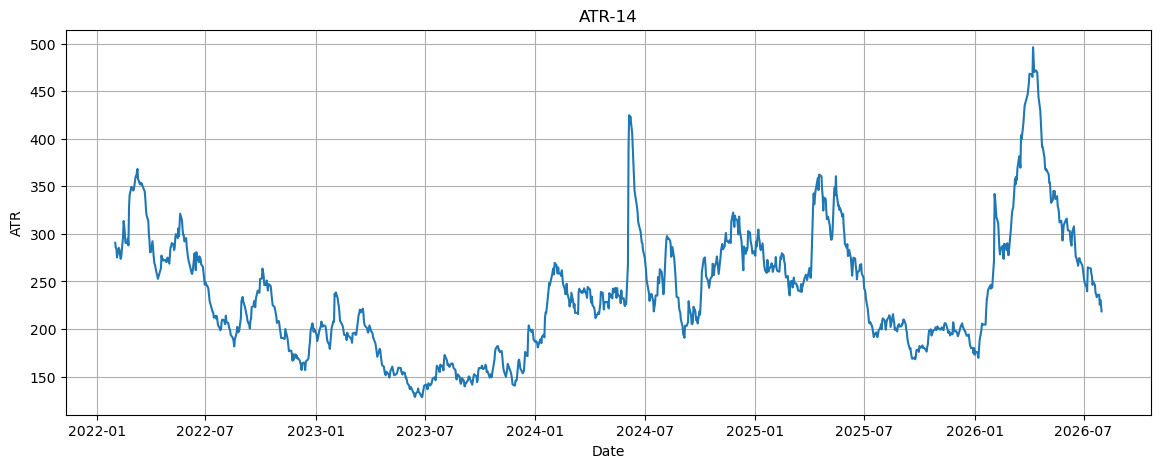

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["atr_14"],
)

plt.title(
    "ATR-14"
)

plt.xlabel("Date")
plt.ylabel("ATR")

plt.grid(True)
plt.show()

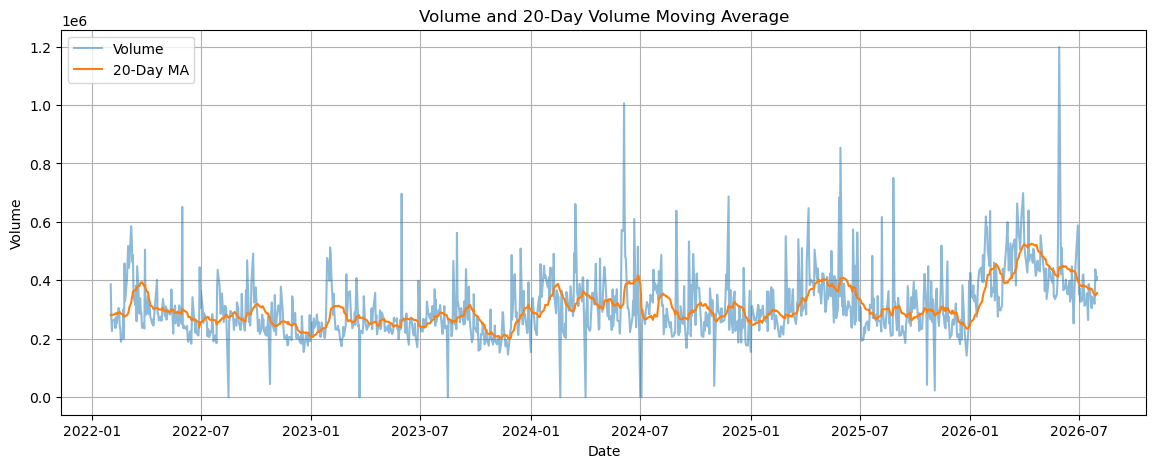

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["Volume"],
    alpha=0.5,
    label="Volume",
)

plt.plot(
    df["Date"],
    df["volume_ma_20"],
    label="20-Day MA",
)

plt.title(
    "Volume and 20-Day Volume Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Volume")

plt.legend()
plt.grid(True)
plt.show()

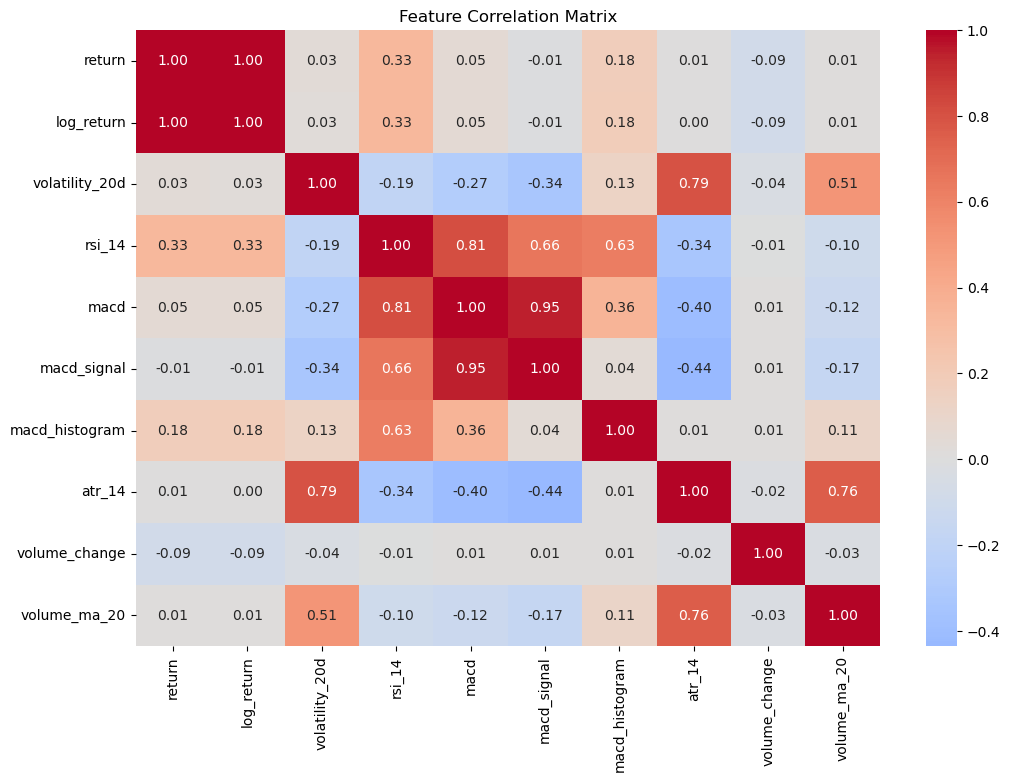

In [14]:
feature_columns = [
    "return",
    "log_return",
    "volatility_20d",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_histogram",
    "atr_14",
    "volume_change",
    "volume_ma_20",
]

correlation = (
    df[feature_columns]
    .corr()
)

plt.figure(
    figsize=(12, 8)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

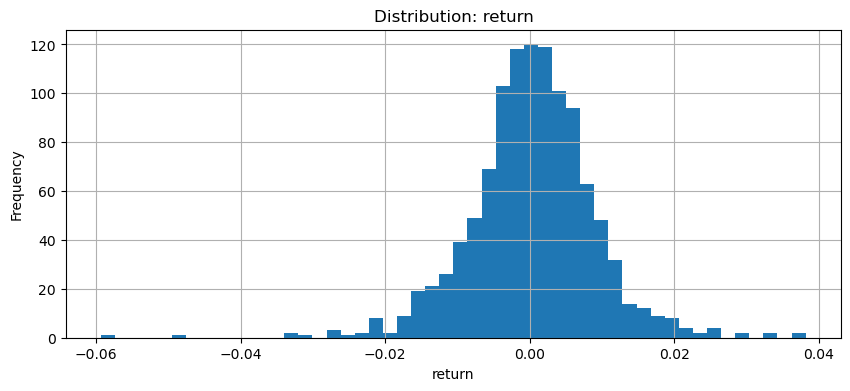

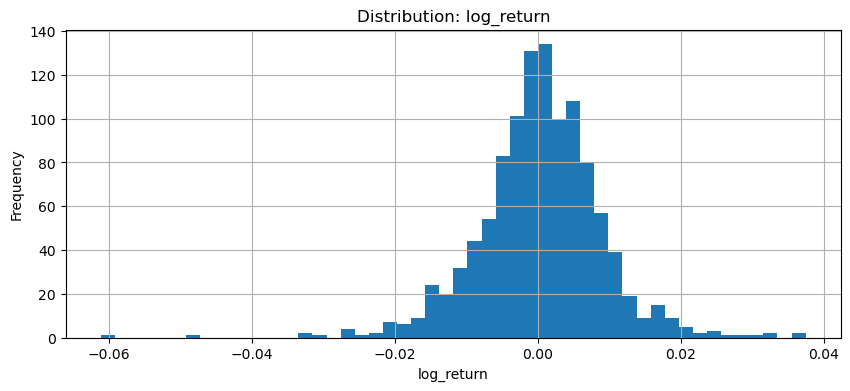

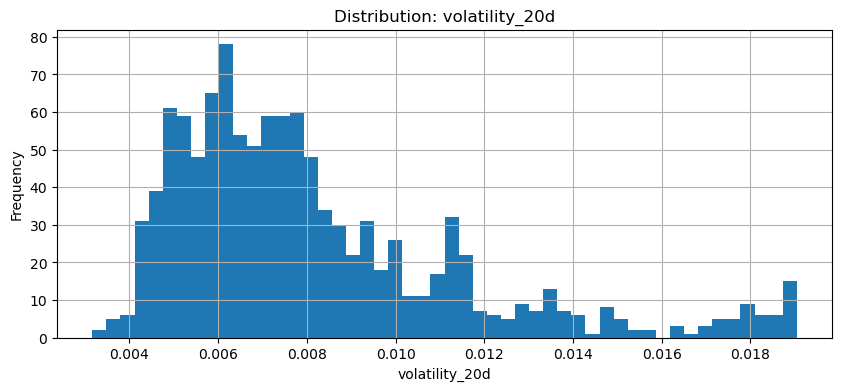

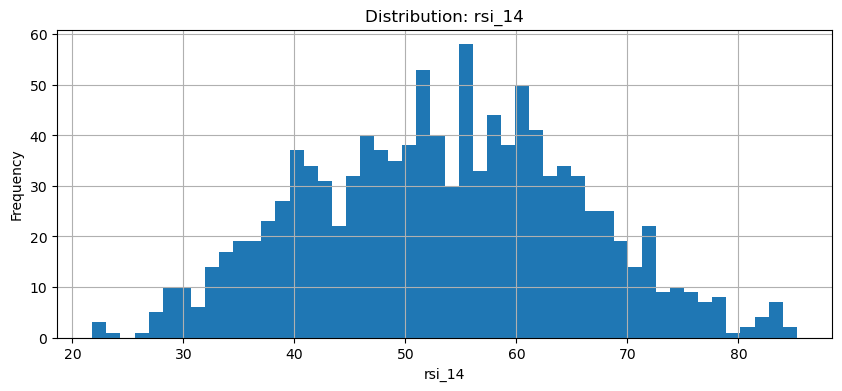

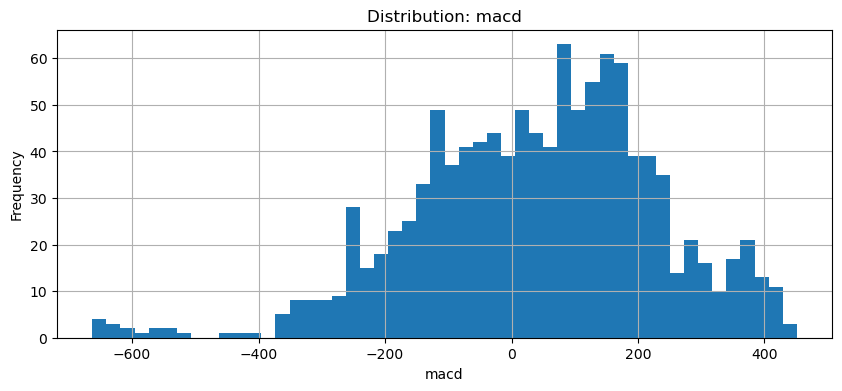

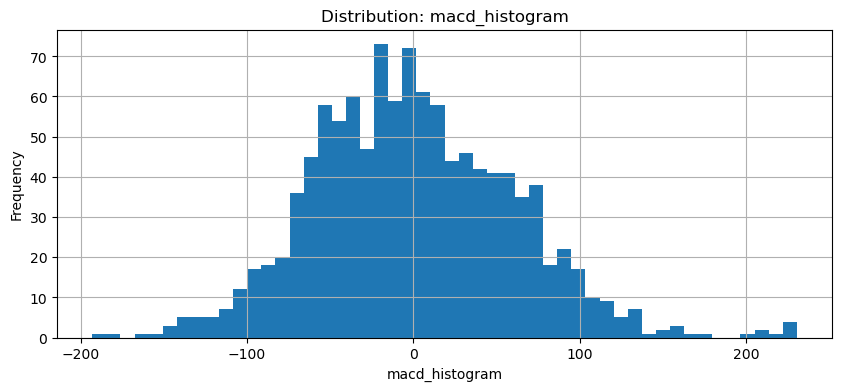

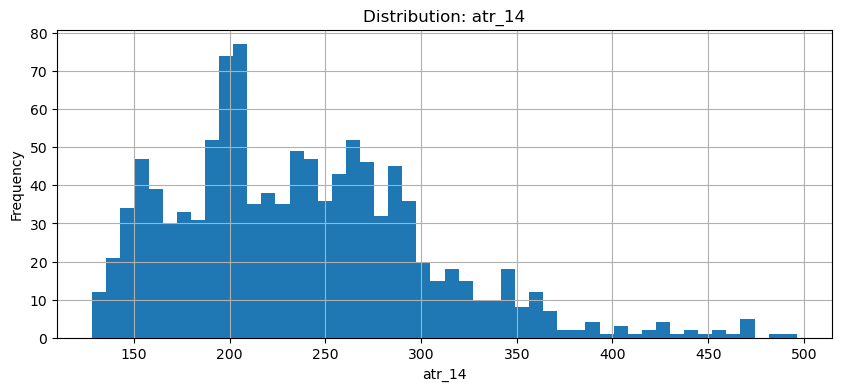

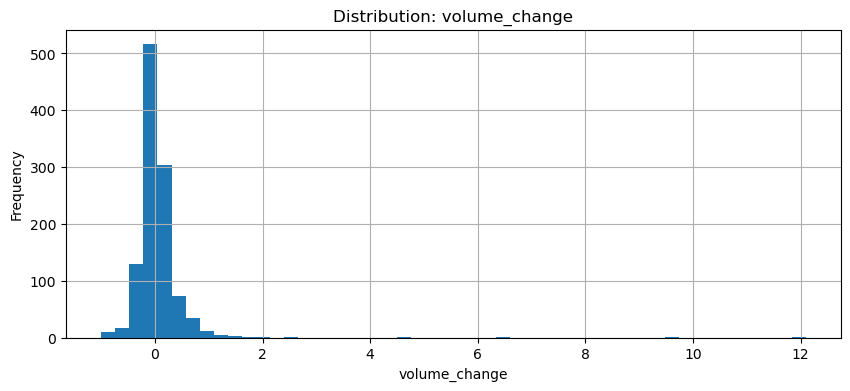

In [15]:
features_to_plot = [
    "return",
    "log_return",
    "volatility_20d",
    "rsi_14",
    "macd",
    "macd_histogram",
    "atr_14",
    "volume_change",
]

for feature in features_to_plot:

    plt.figure(
        figsize=(10, 4)
    )

    plt.hist(
        df[feature],
        bins=50,
    )

    plt.title(
        f"Distribution: {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()